In [2]:
import torch
from diff_gaussian_rasterization import GaussianRasterizationSettings, GaussianRasterizer
from models import GaussianModel
from pytorch3d.renderer import FoVPerspectiveCameras
from utils import compute_camera_K, load_meshes
from torchvision import transforms as T
import os
import torchvision
import lpips
from torch.nn import HuberLoss

In [3]:
def render(viewpoint_camera, pc : GaussianModel, bg_color : torch.Tensor, scaling_modifier = 1.0, override_color = None):
    """
    Render the scene. 
    
    Background tensor (bg_color) must be on GPU!
    """
 
    # Create zero tensor. We will use it to make pytorch return gradients of the 2D (screen-space) means
    screenspace_points = torch.zeros_like(pc.xyz, dtype=pc.xyz.dtype, requires_grad=True, device="cuda") + 0
    try:
        screenspace_points.retain_grad()
    except:
        pass

    # Set up rasterization configuration
    tanfovx = torch.tan(torch.deg2rad(viewpoint_camera.fov) * 0.5)
    tanfovy = torch.tan(torch.deg2rad(viewpoint_camera.fov) * 0.5)

    proj_mat = viewpoint_camera.get_full_projection_transform().get_matrix()
    view_matrix = viewpoint_camera.get_world_to_view_transform().get_matrix().squeeze(0)
    proj_mat = proj_mat.squeeze(0)
    proj_mat[:2,:] *= -1

    raster_settings = GaussianRasterizationSettings(
        image_height=int(256),
        image_width=int(256),
        tanfovx=tanfovx,
        tanfovy=tanfovy,
        bg=bg_color,
        scale_modifier=scaling_modifier,
        viewmatrix=view_matrix,
        projmatrix=proj_mat,
        sh_degree=pc.active_sh_degree,
        campos=viewpoint_camera.get_camera_center().squeeze(0),
        prefiltered=False,
        debug=True,
    )

    rasterizer = GaussianRasterizer(raster_settings=raster_settings)
    
    means3D = pc.xyz
    means2D = screenspace_points
    opacity = pc.opacity

    # If precomputed 3d covariance is provided, use it. If not, then it will be computed from
    # scaling / rotation by the rasterizer.
    scales = None
    rotations = None
    cov3D_precomp = None
    
    scales = pc.scaling
    rotations = pc.rotation

    # If precomputed colors are provided, use them. Otherwise, if it is desired to precompute colors
    # from SHs in Python, do it. If not, then SH -> RGB conversion will be done by rasterizer.
    shs = None
    colors_precomp = None
    if override_color is None:
        shs = pc.features
    else:
        colors_precomp = override_color

    # Rasterize visible Gaussians to image, obtain their radii (on screen). 
    rendered_image, radii = rasterizer(
        means3D = means3D,
        means2D = means2D, # pass torch.zeros_like(means3D) to get gradients of 2D means
        shs = shs,
        colors_precomp = colors_precomp, # None
        opacities = opacity,
        scales = scales,
        rotations = rotations,
        cov3D_precomp = cov3D_precomp) # None

    # Those Gaussians that were frustum culled or had a radius of 0 were not visible.
    # They will be excluded from value updates used in the splitting criteria.
    return {"render": rendered_image,
            "viewspace_points": screenspace_points,
            "visibility_filter" : radii > 0,
            "radii": radii}


In [6]:
device = "cuda"

gm = GaussianModel(device=device)
gm.init_gaussians()

chkpnt_dir = "data/1/chkpnt"
frames = os.listdir('data/1/frames')
frames.sort()

frames = [os.path.join('data/1/frames', frame) for frame in frames]

bg_color = torch.tensor([1, 1, 1], dtype=torch.float32,device=device)
camera = None
max_iterations = 1

huber_loss = HuberLoss()
lpips_loss = lpips.LPIPS(net='vgg').to(device)

lr = {
    'rotation': 0.001,
    'scaling': 0.005,
    'xyz': 0.0025,
    'opacity': 0.05,
    'features': 0.0025
}

gm.get_optimizer(lr=lr)

for i in range(max_iterations):
    for frame in frames[:1]:
        frame_name = os.path.basename(frames[0])[:-4]
        mesh_file = frame_name + '.pkl'

        mesh_file = os.path.join('data/1/meshes', mesh_file)
        frames_file = os.path.join('data/1/frames', frame_name + '.png')

        verts, cameras = load_meshes([mesh_file])
    
        if camera is None:
            camera = FoVPerspectiveCameras(device=device, K=compute_camera_K(verts[0][None], cameras[0][None]))

        gm.update_xyz(verts[0])
        output = render(camera, gm, bg_color , scaling_modifier=1.0, override_color=None)
        
        img = output['render']
        original_image = torchvision.io.read_image(frames_file).float() / 255.0
        original_image = T.Resize((256, 256))(original_image)
        original_image = original_image.to(device)

        loss_huber = huber_loss(img, original_image)
        loss_lpips = lpips_loss(img, original_image)

        loss = loss_huber + loss_lpips
        
        loss.backward()

        with torch.no_grad():
            gm.optimizer.step()
            gm.optimizer.zero_grad(set_to_none=True)

    
    print(f'Iteration: {i}, Huber Loss: {loss_huber.item()}, LPIPS Loss: {loss_lpips.item()}')

    if i % 100 == 0:
        torch.save(gm.capture(), os.path.join(chkpnt_dir, f'chkpnt_{i}.pth'))

            



        
    

/opt/conda/envs/FlashAvatar/lib/python3.7/site-packages/pytorch3d/io/utils.py:65: UserWarning: Faces have invalid indices
  warnings.warn("Faces have invalid indices")
/opt/conda/envs/FlashAvatar/lib/python3.7/site-packages/torchvision/models/_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and will be removed in 0.15, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and will be removed in 0.15, "
/opt/conda/envs/FlashAvatar/lib/python3.7/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and will be removed in 0.15. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /opt/conda/envs/FlashAvatar/lib/python3.7/site-packages/lpips/weights/v0.1/vgg.pth
Iteration: 0, Huber Loss: 0.06107077747583389, LPIPS Loss: 0.18552178144454956


In [1]:
T.ToPILImage()(img.cpu())

NameError: name 'T' is not defined

In [4]:
import torch.utils
import torch.utils.data
from models import FrameMeshDataset
device = 'cuda'
dataset = FrameMeshDataset(frames_dir='data/1/frames', meshes_dir='data/1/meshes', device=device)
data_loader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)

i=0

for frame, verts, cameras, name in dataset:
    print(verts.shape, cameras.shape)
    camera = FoVPerspectiveCameras(device=device, K=compute_camera_K(verts[None], cameras[None]))
    gm.update_xyz(verts)
    output = render(camera, gm, bg_color , scaling_modifier=1.0, override_color=None)
    img = output['render']
    T.ToPILImage()(img.cpu())

    print(img.shape)
    print(frame.shape)

    break
    

torch.Size([6890, 3]) torch.Size([3])


NameError: name 'gm' is not defined

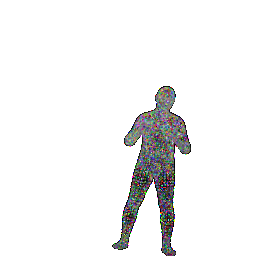

In [17]:

output = render(camera, gm, bg_color , scaling_modifier=1.0, override_color=None)
img = output['render']
T.ToPILImage()(img.cpu())

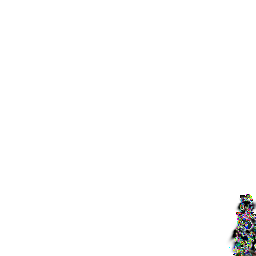

In [25]:
loaded = torch.load('data/1/chkpnt/frame_1_00002.pt')
verts, camera = load_meshes(['data/1/meshes/1_00444.pkl'])

camera = FoVPerspectiveCameras(device=device, K=compute_camera_K(verts[0][None], camera[0][None]))

rotations = loaded[0]
opacity = loaded[1]
features = loaded[2]
scaling = loaded[3]
xyz = loaded[4]

gm.features = features
gm.rotation = rotations
gm.opacity = opacity
gm.scaling = scaling

with torch.no_grad():
    gm.xyz = xyz

output = render(camera, gm, bg_color , scaling_modifier=1.0, override_color=None)
img = output['render']
T.ToPILImage()(img.cpu())


In [18]:
gm1 = GaussianModel(device=device)
gm1.init_gaussians()
camera = None

i = 0

for frame, verts, cameras, name in dataset:
    i+=1
    if camera is None:
        camera = FoVPerspectiveCameras(device=device, K=compute_camera_K(verts[None], cameras[None]))

    gm1.update_xyz(verts)
    output = render(camera, gm1, bg_color , scaling_modifier=1.0, override_color=None)
    img = output['render']

    concatenated_image = torch.cat((img, frame), dim=2)
    concatenated_image = T.ToPILImage()(concatenated_image.cpu())

    concatenated_image.save(f'data/1/check/{name}.png')
    

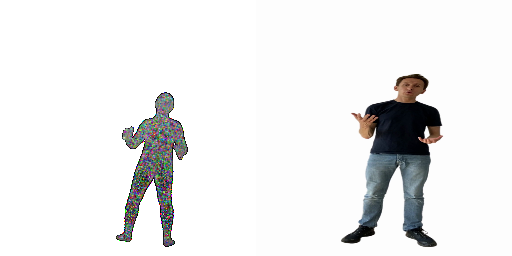